✅ 분석 데이터 로드 완료! (총 10,000행)
--------------------------------------------------
📊 지역별 매출 통계:


,지역,매출 총합,매출 평균
4,서울,11303631,5522.047386
2,대전,10996224,5422.201183
1,광주,10974848,5542.852525
0,경기,10952984,5529.017668
3,부산,10817617,5507.951629


--------------------------------------------------
📈 시각화 그래프 생성 중...


C:\Users\qq\AppData\Local\Temp\ipykernel_21960\1862003821.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_analysis.sort_values(by='매출 총합', ascending=False),
C:\Users\qq\AppData\Local\Temp\ipykernel_21960\1862003821.py:45: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\qq\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


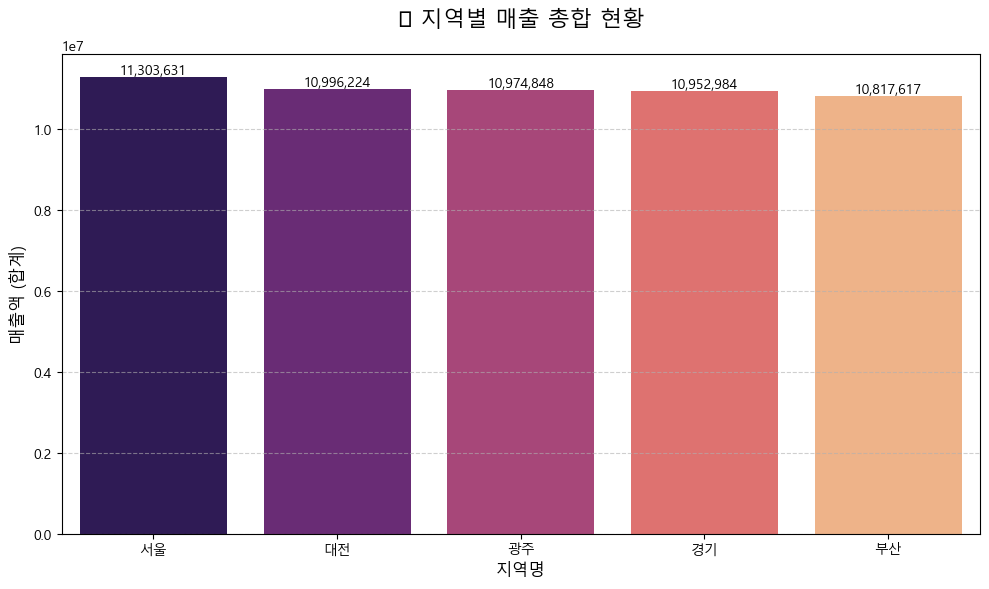

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 깨짐 방지 설정 (Windows 환경 필수 설정)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 전처리 완료된 파일 불러오기
file_path = 'final_analysis_data.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ 분석 데이터 로드 완료! (총 {len(df):,}행)")
    print("-" * 50)

    # [단계 1: 통계 분석] 지역별 매출 합계 및 평균 구하기
    # groupby를 사용하여 데이터를 지역별로 그룹핑합니다.
    region_analysis = df.groupby('지역별 매출')['월별 매출액'].agg(['sum', 'mean']).reset_index()
    region_analysis.columns = ['지역', '매출 총합', '매출 평균']
    
    print("📊 지역별 매출 통계:")
    display(region_analysis.sort_values(by='매출 총합', ascending=False))
    print("-" * 50)

    # [단계 2: 시각화] 지역별 매출 현황 그래프 그리기
    print("📈 시각화 그래프 생성 중...")
    plt.figure(figsize=(10, 6))
    
    # Seaborn을 활용한 세련된 막대 그래프
    sns.barplot(data=region_analysis.sort_values(by='매출 총합', ascending=False), 
                x='지역', y='매출 총합', palette='magma')

    # 그래프 꾸미기
    plt.title('📍 지역별 매출 총합 현황', fontsize=16, pad=20)
    plt.xlabel('지역명', fontsize=12)
    plt.ylabel('매출액 (합계)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # 수치 텍스트 표시 (그래프 위에 금액 표시)
    for i, row in region_analysis.sort_values(by='매출 총합', ascending=False).reset_index().iterrows():
        plt.text(i, row['매출 총합'], f"{int(row['매출 총합']):,}", 
                 ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ 분석 중 에러 발생: {e}")